In [ ]:
from music21 import converter, instrument, note, chord, stream
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn   

In [2]:
def extract_notes(file):
    notes = []
    pick = None
    for j in file:
        # instrument is a method from music21
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            pick = part.recurse()
            for element in pick:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))

    return notes

In [ ]:
def load_composer_midi(composer_dir):
    midi_files = []
    for root, dirs, files in os.walk(composer_dir):
        for file in files:
            if file.endswith(".mid"):
                path = os.path.join(root, file)
                try:
                    midi = converter.parse(path)
                    midi_files.append(midi)
                except:
                    print(f"Error parsing {file}, skipping.")
    return midi_files

In [ ]:
chopin_dir = "chopin"
chopin_files = load_composer_midi(chopin_dir)
corpus = extract_notes(chopin_files)

In [5]:
from collections import Counter

In [6]:
note_counts = Counter(corpus)
min_occurrences = 5
filtered_corpus = [n for n in corpus if note_counts[n] >= min_occurrences]

In [7]:
unique_notes = sorted(list(set(filtered_corpus)))
note_to_int = {note: i for i, note in enumerate(unique_notes)}
int_to_note = {i: note for i, note in enumerate(unique_notes)}


In [8]:
seq_length = 40
X = []
y = []
for i in range(len(filtered_corpus) - seq_length):
    seq_in = filtered_corpus[i:i + seq_length]
    seq_out = filtered_corpus[i + seq_length]
    X.append([note_to_int[note] for note in seq_in])
    y.append(note_to_int[seq_out])

In [ ]:
class MusicDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
X = torch.tensor(X, dtype=torch.long).unsqueeze(-1)  # Use torch.long
y = torch.tensor(y, dtype=torch.long)
num_classes = y.max().item() + 1
one_hot = torch.nn.functional.one_hot(y, num_classes=num_classes)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = one_hot[:split], one_hot[split:]

batch_size = 64
train_loader = DataLoader(MusicDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(MusicDataset(X_test, y_test), batch_size=batch_size, shuffle=False)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Data preparation

# Define MusicLSTM
class MusicLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size1, hidden_size2, output_size):
        super(MusicLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size1, num_layers=2, 
                           batch_first=True, dropout=0.3)
        self.fc1 = nn.Linear(hidden_size1, hidden_size2)
        self.fc2 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = lstm_out[:, -1, :]
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Initialize model
vocab_size = num_classes
embedding_dim = 128
hidden_size1 = 512
hidden_size2 = 256
model = MusicLSTM(vocab_size, embedding_dim, hidden_size1, hidden_size2, num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
test_losses = []
epochs = []
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.squeeze(-1).to(device)
        targets = targets.argmax(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.squeeze(-1).to(device)
            targets = targets.argmax(1).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
    
    test_loss /= len(test_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}')
    test_losses.append(test_loss)

Epoch 1/50 | Train Loss: 4.1112 | Test Loss: 4.2342
Epoch 2/50 | Train Loss: 3.2392 | Test Loss: 4.2885
Epoch 3/50 | Train Loss: 2.5143 | Test Loss: 4.4215
Epoch 4/50 | Train Loss: 1.9147 | Test Loss: 4.7936
Epoch 5/50 | Train Loss: 1.4442 | Test Loss: 5.2913
Epoch 6/50 | Train Loss: 1.0809 | Test Loss: 5.7315
Epoch 7/50 | Train Loss: 0.8288 | Test Loss: 6.4016
Epoch 8/50 | Train Loss: 0.6459 | Test Loss: 6.7262
Epoch 9/50 | Train Loss: 0.5332 | Test Loss: 7.1424
Epoch 10/50 | Train Loss: 0.4654 | Test Loss: 7.4286
Epoch 11/50 | Train Loss: 0.4311 | Test Loss: 7.6941
Epoch 12/50 | Train Loss: 0.3900 | Test Loss: 7.8758
Epoch 13/50 | Train Loss: 0.3708 | Test Loss: 8.2109
Epoch 14/50 | Train Loss: 0.3501 | Test Loss: 8.2260
Epoch 15/50 | Train Loss: 0.3566 | Test Loss: 8.2175
Epoch 16/50 | Train Loss: 0.3139 | Test Loss: 8.4638
Epoch 17/50 | Train Loss: 0.3097 | Test Loss: 8.5867
Epoch 18/50 | Train Loss: 0.3063 | Test Loss: 8.7555
Epoch 19/50 | Train Loss: 0.3049 | Test Loss: 8.8390
Ep

In [14]:
import matplotlib.pyplot as plt
import numpy as np

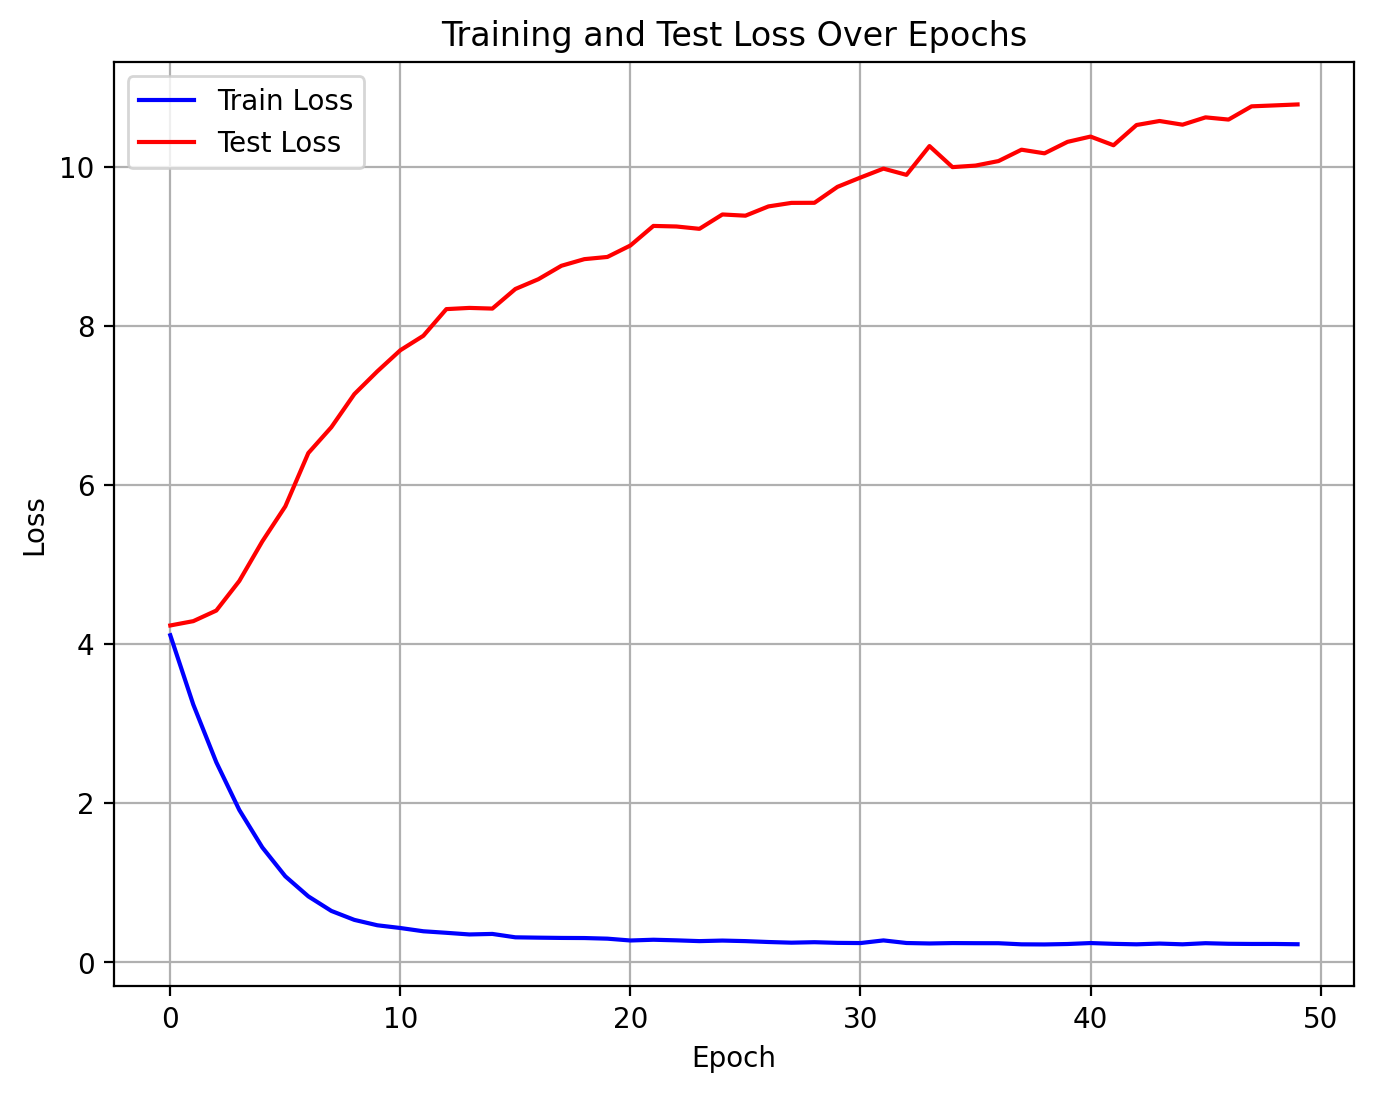

In [15]:
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(train_losses, 'b-', label='Train Loss')
plt.plot(test_losses, 'r-', label='Test Loss')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

In [16]:

def validate_notes(corpus, note_to_int, int_to_note):
    valid_notes = []
    valid_note_to_int = {}
    valid_int_to_note = {}
    index = 0
    for note in set(corpus):
        try:
            if '.' in note:  # Chord
                pitches = note.split('.')
                chord.Chord([int(p) for p in pitches]) 
            else: 
                note.Note(note)  
            valid_notes.append(note)
            valid_note_to_int[note] = index
            valid_int_to_note[index] = note
            index += 1
        except:
            print(f"Skipping invalid note/chord: {note}")
    return valid_notes, valid_note_to_int, valid_int_to_note

filtered_corpus, note_to_int, int_to_note = validate_notes(filtered_corpus, note_to_int, int_to_note)
print(f"Valid vocabulary size: {len(note_to_int)}")
print(f"Sample valid notes/chords: {list(int_to_note.values())[:10]}")

Skipping invalid note/chord: 5
Skipping invalid note/chord: 10
Skipping invalid note/chord: C#4
Skipping invalid note/chord: B3
Skipping invalid note/chord: 0
Skipping invalid note/chord: G6
Skipping invalid note/chord: G1
Skipping invalid note/chord: B-4
Skipping invalid note/chord: B-3
Skipping invalid note/chord: G#3
Skipping invalid note/chord: 1
Skipping invalid note/chord: 8
Skipping invalid note/chord: C5
Skipping invalid note/chord: C#6
Skipping invalid note/chord: F#1
Skipping invalid note/chord: B5
Skipping invalid note/chord: E-6
Skipping invalid note/chord: F#3
Skipping invalid note/chord: E-7
Skipping invalid note/chord: E3
Skipping invalid note/chord: E4
Skipping invalid note/chord: B-6
Skipping invalid note/chord: A4
Skipping invalid note/chord: C#5
Skipping invalid note/chord: G#2
Skipping invalid note/chord: A5
Skipping invalid note/chord: A2
Skipping invalid note/chord: A3
Skipping invalid note/chord: F2
Skipping invalid note/chord: E5
Skipping invalid note/chord: G#4

In [17]:
model.eval()

seed_sequence = filtered_corpus[:seq_length]  
input_indices = [note_to_int[note] for note in seed_sequence]

def generate_music(model, seed_indices, generate_length=100):
    generated_indices = seed_indices.copy()
    with torch.no_grad():
        for _ in range(generate_length - len(seed_indices)):
            input_tensor = torch.tensor([generated_indices[-seq_length:]], dtype=torch.long).to(device)
            output = model(input_tensor)
            next_index = torch.argmax(output, dim=1).item()
            generated_indices.append(next_index)
    return [int_to_note.get(idx, 'C4') for idx in generated_indices] 

generated_notes = generate_music(model, input_indices)

def save_to_midi(notes, output_file='simple_music.mid'):
    output_stream = stream.Stream()
    for item in notes:
        try:
            if '.' in item:  
                pitches = item.split('.')
                c = chord.Chord([int(p) for p in pitches])
                c.quarterLength = 0.5
                output_stream.append(c)
            else:  
                n = note.Note(item)
                n.quarterLength = 0.5
                output_stream.append(n)
        except Exception as e:
            print(f"Skipping invalid note/chord '{item}': {e}")
    output_stream.write('midi', output_file) 
    print(f"Saved music to {output_file}")

save_to_midi(generated_notes, 'simple_music.mid')

print(f"Generated music sequence: {generated_notes}")

Saved music to simple_music.mid
Generated music sequence: ['3.6', '7.10.1.3', '11.2.4', '10.1.4.6', '3.7.9', '6.7.0', '0.1', '1.4.8', '10.3', '3.6.10', '3.5.8', '11.1', '0.4', '0.3', '5.11', '1.7', '3.7', '6.8.0', '6.11', '9.11', '3.5.10', '0.5.6', '1.5.9', '0.4.5', '10.2', '7.8.10.2', '10.0.3.6', '3.7.11', '5.7.10', '11.3.5', '2.4.7', '8.11.3', '8.11.1', '5.9', '4.7', '7.10.2', '5.8.11', '10.1.5', '4.7.9', '1.4', '2.4.5', '10.11', '4.5.7', '6.8.0', '2.4.5', '6.8.0', '2.4.5', '6.8.0', '2.4.5', 'C4', '10.1.4.6', '2.4.5', '10.1.4.6', '2.4.5', '10.1.4.6', '10.1.5', 'C4', '1.7', '10.1.5', '1.7', '10.1.5', '1.7', '3.7', 'C4', '2.4.5', '2.4.5', '5.8.10', '2.4.5', '4.6.10', '6.8.0', 'C4', '7.10', '6.8.0', '2.4.5', '6.8.0', '6.8.0', 'C4', '0.2.6.8', '7.10', '10.1.4.6', '5.7', '4.5.7', '11.1', '0.5', '1.5', '1.3.6', '5.7', '4.5.7', '11.1', '0.5', '1.5', '1.3.6', '5.7', '4.5.7', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4']


In [18]:
chopin_dir = "mozart"
chopin_files = load_composer_midi(chopin_dir)

In [19]:
corpus = extract_notes(chopin_files)

In [20]:
note_counts = Counter(corpus)
min_occurrences = 5
filtered_corpus = [n for n in corpus if note_counts[n] >= min_occurrences]

In [21]:
unique_notes = sorted(list(set(filtered_corpus)))
note_to_int = {note: i for i, note in enumerate(unique_notes)}
int_to_note = {i: note for i, note in enumerate(unique_notes)}


In [22]:
seq_length = 40
X = []
y = []
for i in range(len(filtered_corpus) - seq_length):
    seq_in = filtered_corpus[i:i + seq_length]
    seq_out = filtered_corpus[i + seq_length]
    X.append([note_to_int[note] for note in seq_in])
    y.append(note_to_int[seq_out])

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

class MusicDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X = torch.tensor(X, dtype=torch.long)  
y = torch.tensor(y, dtype=torch.long)
num_classes = y.max().item() + 1
one_hot = torch.nn.functional.one_hot(y, num_classes=num_classes)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = one_hot[:split], one_hot[split:]
batch_size = 64
train_loader = DataLoader(MusicDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(MusicDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

class MusicLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size1, hidden_size2,output_size):
        super(MusicLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout_embed = nn.Dropout(0.25)
        self.lstm = nn.LSTM(embedding_dim, hidden_size1, num_layers=1, 
                            batch_first=True, dropout=0.0)
        self.dropout_lstm = nn.Dropout(0.25)
        self.fc1 = nn.Linear(hidden_size1, hidden_size2)
        self.dropout_fc1 = nn.Dropout(0.25)
        self.fc2 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout_embed(embedded)
        lstm_out, _ = self.lstm(embedded)
        out = lstm_out[:, -1, :]
        out = self.dropout_lstm(out)
        out = self.fc1(out)
        out = self.dropout_fc1(out)
        out = self.fc2(out)
        return out

# Initialize model
vocab_size = num_classes
model = MusicLSTM(vocab_size, embedding_dim=64, hidden_size1=256, hidden_size2=128, output_size=num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

train_losses = []
test_losses = []
epochs = []
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.squeeze(-1).to(device)
        targets = targets.argmax(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.squeeze(-1).to(device)
            targets = targets.argmax(1).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
    
    test_loss /= len(test_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}')
    test_losses.append(test_loss)

Epoch 1/50 | Train Loss: 3.8350 | Test Loss: 3.3708
Epoch 2/50 | Train Loss: 3.3064 | Test Loss: 3.2496
Epoch 3/50 | Train Loss: 3.0520 | Test Loss: 3.2237
Epoch 4/50 | Train Loss: 2.8355 | Test Loss: 3.2312
Epoch 5/50 | Train Loss: 2.6541 | Test Loss: 3.2618
Epoch 6/50 | Train Loss: 2.4910 | Test Loss: 3.3479
Epoch 7/50 | Train Loss: 2.3571 | Test Loss: 3.3805
Epoch 8/50 | Train Loss: 2.2438 | Test Loss: 3.4271
Epoch 9/50 | Train Loss: 2.1339 | Test Loss: 3.4766
Epoch 10/50 | Train Loss: 2.0454 | Test Loss: 3.5678
Epoch 11/50 | Train Loss: 1.9588 | Test Loss: 3.5758
Epoch 12/50 | Train Loss: 1.8811 | Test Loss: 3.6524
Epoch 13/50 | Train Loss: 1.8218 | Test Loss: 3.6830
Epoch 14/50 | Train Loss: 1.7707 | Test Loss: 3.7489
Epoch 15/50 | Train Loss: 1.7148 | Test Loss: 3.7893
Epoch 16/50 | Train Loss: 1.6629 | Test Loss: 3.8437
Epoch 17/50 | Train Loss: 1.6156 | Test Loss: 3.8744
Epoch 18/50 | Train Loss: 1.5802 | Test Loss: 3.9199
Epoch 19/50 | Train Loss: 1.5409 | Test Loss: 3.9142
Ep

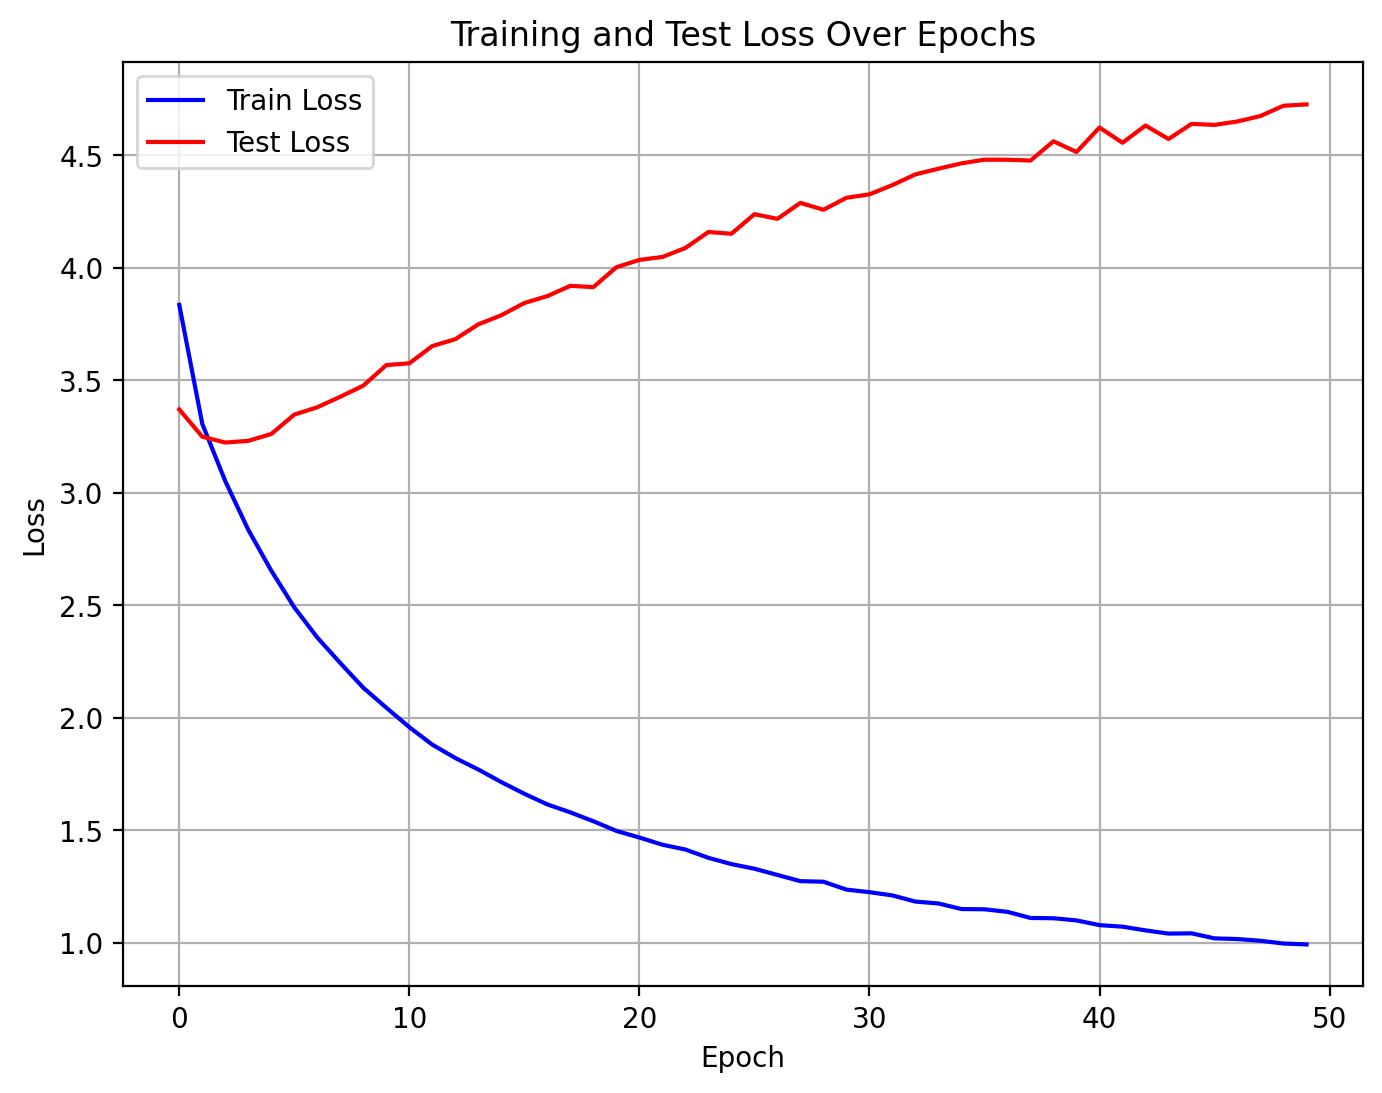

In [24]:
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(train_losses, 'b-', label='Train Loss')
plt.plot(test_losses, 'r-', label='Test Loss')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()